In [1]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import scanpy as sc
import pandas as pd
import anndata as ad
from tqdm import tqdm
from scipy import sparse

import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/low_dimensional_rep
scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [2]:
import torch 
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cpu


In [3]:
import sys
sys.path.append('../../utils')
from functions import * 

In [4]:
from importlib import reload
import sys

# Replace 'PATH_TO_REPOSITORY' with the actual path to the repository containing load_cluster_data.py
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-lda/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [5]:
# Now you can import the module
from load_cluster_data import load_cluster_data
import splicing_PCA_utils
from splicing_PCA_utils import make_Y

In [6]:
import gc

import numpy as np
import seaborn as sns
import scipy.sparse as sp

from splicing_PCA_utils import make_Y

### Load data

In [7]:
# Metadata file:
organ = 'Marrow'
metadata_file = '/gpfs/commons/groups/knowles_lab/data/tabula_muris/smart_seq/d8a0c006-2991-5ddb-8ed8-7b7e8c187fe3/all_tabula_muris_samples_w_celltype_column.txt'
metadata = pd.read_csv(metadata_file, sep='\t', index_col=0)
print("Loaded metadata file!")
print_separator()

# Subset the metadata file to only include the organ of interest:
metadata = metadata[metadata['tissue'].str.contains(organ)]
print("The number of cells in the metadata corresponding to the organ of interest is: " + str(len(metadata.index)))
print_separator()

cells_freq = metadata.groupby(['tissue', 'subtissue', 'cell_ontology_class']).size()
print("The breakdown of cell types in the organ of interest is: ")
print(cells_freq)
print_separator()


Loaded metadata file!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The number of cells in the metadata corresponding to the organ of interest is: 5037
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The breakdown of cell types in the organ of interest is: 
tissue  subtissue     cell_ontology_class                        
Marrow  B-cells       B cell                                           3
                      Slamf1-negative multipotent progenitor cell      1
                      granulocyte                                      7
                      granulocyte monocyte progenitor cell             1
                      granulocytopoietic cell                          1
                      immature B cell                                220
                      immature NK T cell                               2
                      immature natural ki

In [8]:
input_file = '/gpfs/commons/scratch/kisaev/ss_tabulamuris_test/Leaflet/clustered_junctions_noanno.txt_anno_free_50_500000_10_5_0.1_single_cell.h5'

# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/scratch/kisaev/ss_tabulamuris_test/Leaflet/Marrow/'

In [9]:
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
    input_folder = input_files_folder) 

Reading in data from folder ...
/gpfs/commons/scratch/kisaev/ss_tabulamuris_test/Leaflet/Marrow/
Finished reading in data from folder ...
['Marrow_naive_B_cell' 'Marrow_common_lymphoid_progenitor'
 'Marrow_granulocyte_monocyte_progenitor_cell'
 'Marrow_mature_natural_killer_cell' 'Marrow_granulocytopoietic_cell'
 'Marrow_Slamf1-negative_multipotent_progenitor_cell'
 'Marrow_pre-natural_killer_cell' 'Marrow_granulocyte' 'Marrow_basophil'
 'Marrow_regulatory_T_cell'
 'Marrow_Slamf1-positive_multipotent_progenitor_cell'
 'Marrow_hematopoietic_precursor_cell' 'Marrow_B_cell'
 'Marrow_immature_natural_killer_cell' 'Marrow_immature_NK_T_cell'
 'Marrow_precursor_B_cell' 'Marrow_late_pro-B_cell'
 'Marrow_immature_B_cell' 'Marrow_monocyte' 'Marrow_macrophage'
 'Marrow_megakaryocyte-erythroid_progenitor_cell' 'Marrow_immature_T_cell']
5037
5037
38996
38996
The number of junctions in the data is:  38996
The number of cells in the data is:  5037
The number of cell types in the data is:  22


In [10]:
final_data.tail()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type
40633462,5036,38652,0.0,12,12.0,0.0,P9-MAA001888-3_39_F-1-1,Marrow_regulatory_T_cell
40633463,5036,38713,0.0,71,71.0,0.0,P9-MAA001888-3_39_F-1-1,Marrow_regulatory_T_cell
40633464,5036,38714,0.0,71,71.0,0.0,P9-MAA001888-3_39_F-1-1,Marrow_regulatory_T_cell
40633465,5036,38717,0.0,45,45.0,0.0,P9-MAA001888-3_39_F-1-1,Marrow_regulatory_T_cell
40633466,5036,38842,0.0,10,10.0,0.0,P9-MAA001888-3_39_F-1-1,Marrow_regulatory_T_cell


In [11]:
# still do preprocessing in scipy
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)

In [12]:
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [13]:
# set up data for nuc norm PCA
Y_data, w = splicing_PCA_utils.make_Y(
    junc_counts, cluster_counts, float_type)

In [14]:
# turn Y_data into COO matrix 
Y_data_coo = sp.coo_matrix((Y_data, indices))
Y_data_coo

<5037x38996 sparse matrix of type '<class 'numpy.float64'>'
	with 40633467 stored elements in COOrdinate format>

In [17]:
# make anndata object using Y_data as "count matrix"
adata = ad.AnnData(X=Y_data_coo)

/scratch/ipykernel_33969/247655266.py:2: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(X=Y_data_coo)


In [18]:
adata
adata.obs_names = cell_ids_conversion.cell_id
adata.var_names = junction_ids_conversion.junction_id

In [19]:
# ensure cells in metadata are in the same order as in adata
metadata = metadata.loc[adata.obs_names]
metadata.head()

,cell_ontology_class,free_annotation,mouse.id,subtissue,tissue,cell_type
cell_id,,,,,,
A1-D041912-3_8_M-1-1,granulocyte,NaN,3_8_M,Granulocytes,Marrow,Marrow_granulocyte
A1-MAA000409-3_10_M-1-1,basophil,NaN,3_10_M,Granulocytes,Marrow,Marrow_basophil
A1-MAA000596-3_9_M-1-1,Slamf1-positive multipotent progenitor cell,NaN,3_9_M,KLS,Marrow,Marrow_Slamf1-positive_multipotent_progenitor_...
A1-MAA000600-3_8_M-1-1,megakaryocyte-erythroid progenitor cell,NaN,3_8_M,KLS,Marrow,Marrow_megakaryocyte-erythroid_progenitor_cell
A1-MAA000652-3_10_M-1-1,immature B cell,NaN,3_10_M,B-cells,Marrow,Marrow_immature_B_cell


In [20]:
metadata["cell_id"] = metadata.index
# remove index from metadata
metadata = metadata.reset_index(drop=True)
# remove free_annotation column from metadata since it doesn't contain any info 
metadata = metadata.drop(columns=['free_annotation'])
# add metadata 
adata.obs = metadata

### Run PCA on these mean 0 centers junction usage ratios

In [21]:
print("The number of cells and junctions going into PCA is: " + str(adata.shape))

The number of cells and junctions going into PCA is: (5037, 38996)


In [22]:
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    with n_comps=50
    finished (0:01:15)


/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


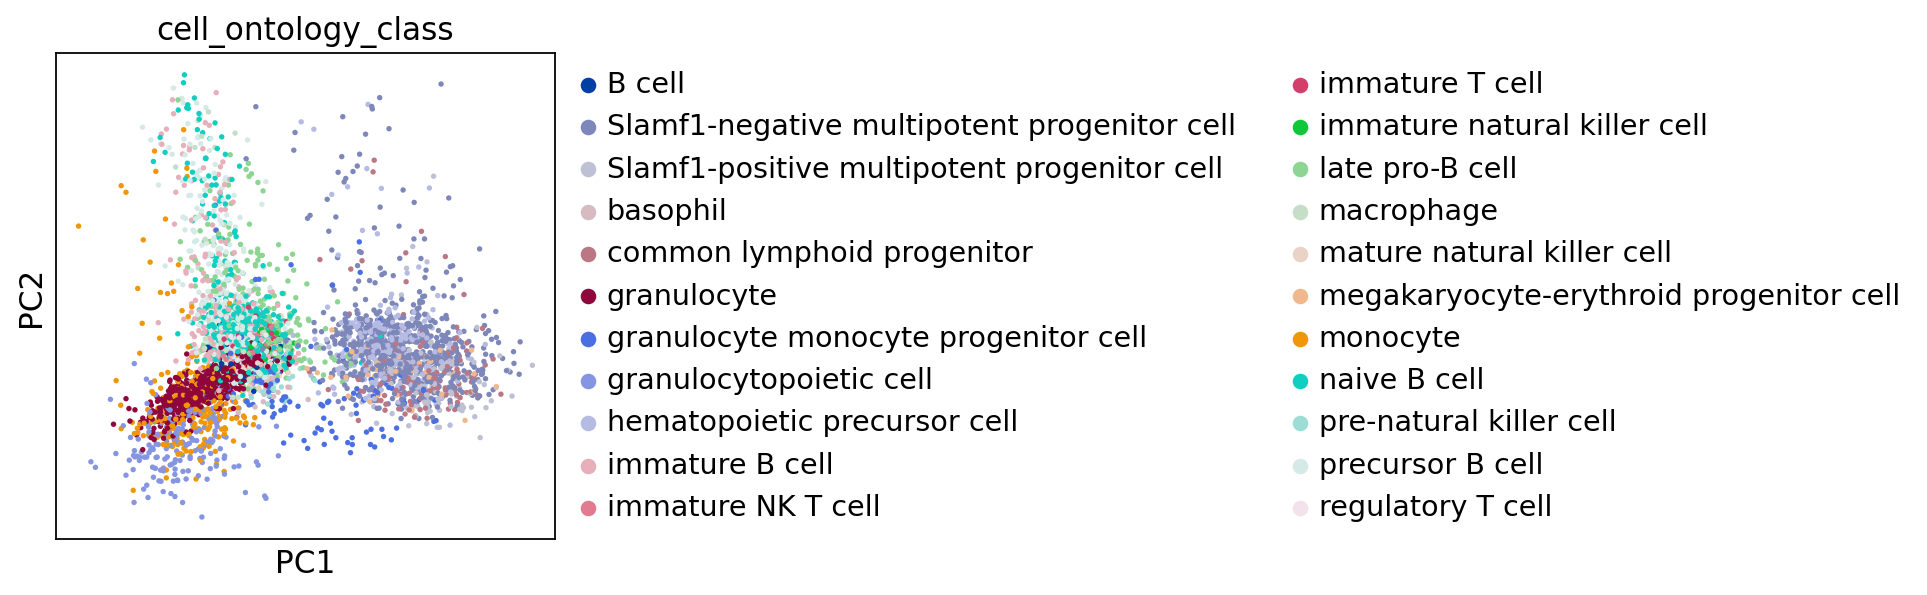

In [23]:
sc.pl.pca(adata, color='cell_ontology_class')

In [24]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)


In [25]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:17)


/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


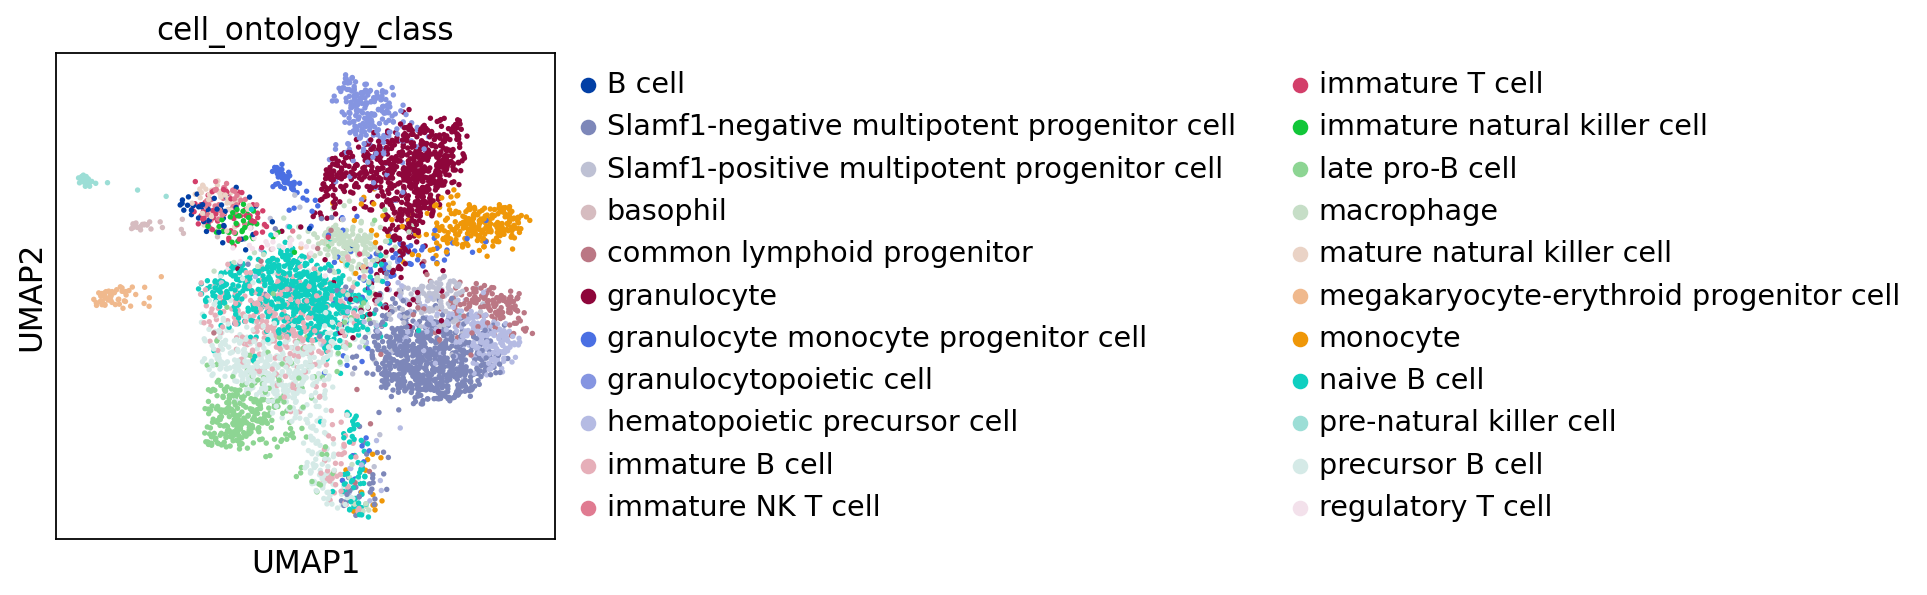

In [26]:
sc.pl.umap(adata, color=['cell_ontology_class'])

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


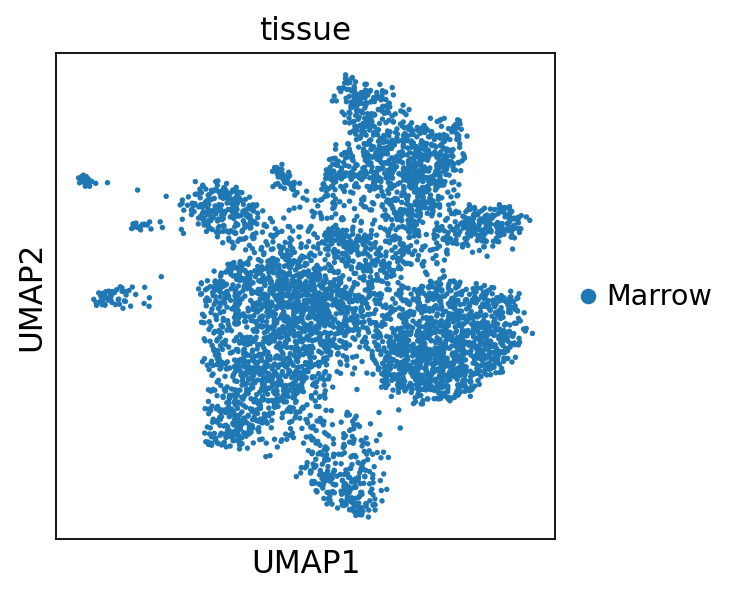

In [27]:
sc.pl.umap(adata, color=['tissue'])

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


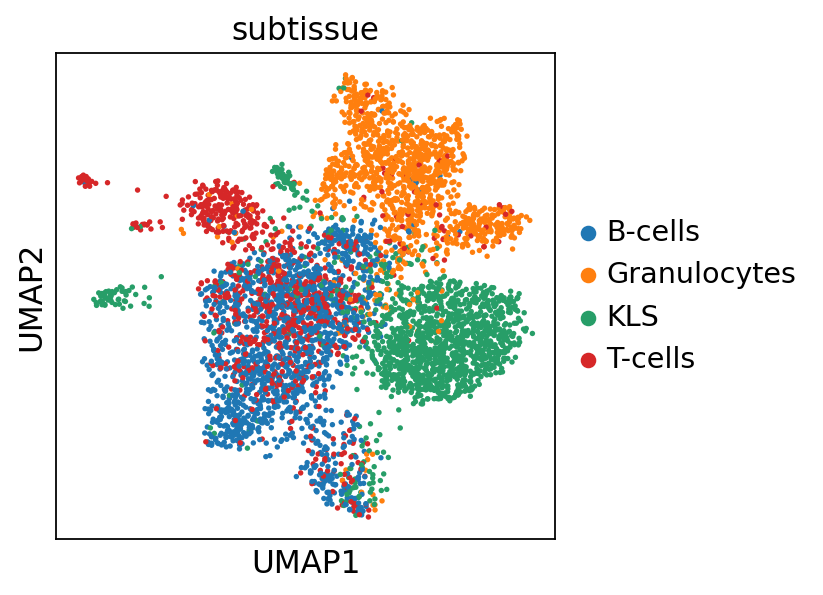

In [28]:
sc.pl.umap(adata, color=['subtissue'])

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


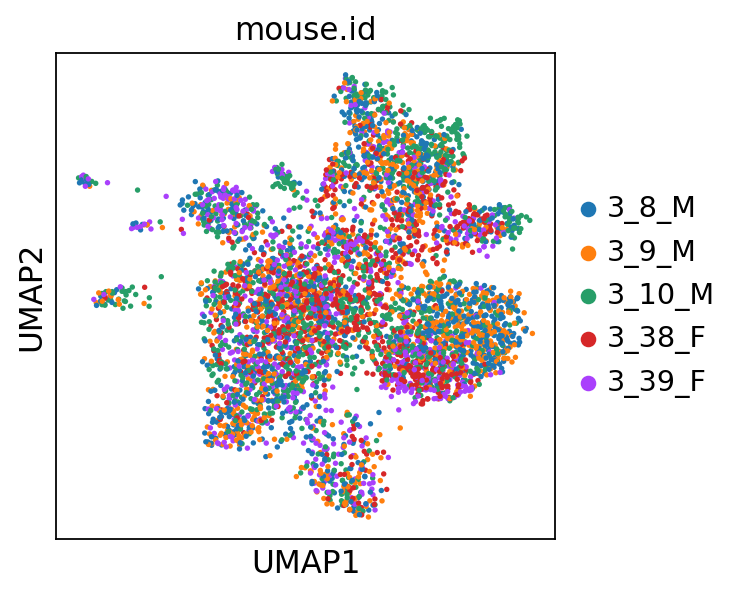

In [29]:
sc.pl.umap(adata, color=['mouse.id'])